<a href="https://colab.research.google.com/github/devwoo41/Experiments/blob/master/CoT_Prompting/cot_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chain-of-Thought Prompting 논문 재현 실험

**논문**: Wei et al., 2022, *"Chain-of-Thought Prompting Elicits Reasoning in Large Language Models"* ([arxiv:2201.11903](https://arxiv.org/pdf/2201.11903))

이 노트북은 논문의 핵심 주장을 **Colab A100 40GB** 환경에서 오픈소스 모델만으로 재현·검증합니다.

### 검증할 세 가지 주장
1. **Few-shot CoT prompting**이 표준 prompting보다 reasoning task에서 정확도를 크게 끌어올린다 (논문 Table 1, 2, 3).
2. **Scale effect**: CoT의 이득은 모델이 충분히 커야 나타나는 *emergent ability*다 (논문 Figure 4).
3. **Self-Consistency** (Wang et al., 2022) 다수결을 결합하면 CoT 정확도가 추가로 상승한다.

### 실험 설계
| 항목 | 값 |
|---|---|
| Scale ladder (5개) | Qwen2.5-Instruct **0.5B · 1.5B · 3B · 7B** (fp16) + **32B-AWQ** (4bit) |
| 태스크 (5개) | GSM8K · Last Letter Concat · Coin Flip · CommonsenseQA · StrategyQA |
| 평가 문항 수 | 0.5B~7B: 각 300 / 32B: 각 150 (시간 절약) |
| 프롬프트 조건 (3개) | Standard 8-shot · CoT 8-shot · Self-Consistency (CoT + sampling) |
| Self-Consistency 샘플 수 | 0.5B~7B: n=10 / 32B: n=5 |
| 추론 엔진 | vLLM (PagedAttention, batch sampling 효율적) |

### 원 논문과의 차이
원 논문은 GPT-3 (175B), PaLM (540B) 같은 비공개 거대 모델을 사용했습니다. 우리는 동일 패밀리(`Qwen2.5-Instruct`) 내 5개 크기로 scale 변수를 깔끔하게 잡습니다. 32B는 AWQ 4bit 양자화로 A100 40GB에 적재 (가중치 ~16GB + KV cache 여유).

논문의 emergent threshold(~62B)에 32B가 가장 가깝지만, 그래도 미달합니다. 따라서 "급격한 emergent kink"보다는 **scale에 따른 점진적 증가 추세**를 관찰하는 실험이 됩니다 — 이 한계는 결과 해석에 반영합니다.

> ⚠️ **Colab 사전 준비**: 런타임 유형을 `A100 GPU`로 설정하세요 (런타임 → 런타임 유형 변경).


## 1. 환경 설정

GPU 확인 후 필요한 패키지를 설치합니다. vLLM은 PagedAttention으로 sampling을 매우 효율적으로 처리해 Self-Consistency 실험에 적합합니다. AWQ 4bit 모델도 vLLM이 빌트인 지원하므로 별도 패키지 불필요합니다.

> ⚠️ **Colab/Jupyter 호환성 처리**:
> - vLLM 0.7+의 V1 엔진은 Jupyter의 `ipykernel` stdout이 `fileno()`를 지원하지 않아 `io.UnsupportedOperation: fileno` 에러로 초기화 실패합니다.
> - vLLM 0.6.x로 다운그레이드하면 numpy 1.x 강제 → Colab의 사전 설치 패키지들(numpy 2.x ABI로 컴파일됨)과 binary 충돌.
> - 따라서 **vLLM 최신(numpy 2 호환) + V1 엔진 비활성화 + stdout fileno monkey-patch** 조합이 정답입니다.
>
> 이 셀들은 vLLM이 import되기 **전에** 실행돼야 효과 있습니다. 이미 vLLM이 에러로 죽었다면 **`런타임 → 런타임 다시 시작`** 후 노트북 첫 셀부터 다시 실행하세요.


In [ ]:
!nvidia-smi

Thu May 14 01:19:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   35C    P0             53W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
# vLLM 최신 + datasets 등 설치 (vLLM 0.7+는 numpy 2.x와 호환됨)
# AWQ 4bit는 vLLM이 빌트인 지원하므로 autoawq 별도 설치 불필요
!pip install -q vllm datasets pandas matplotlib seaborn tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.4/244.4 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 100.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.3/194.3 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 161.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 129.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 102.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/

### 1.1 Colab/Jupyter 호환성 패치 (V1 엔진 우회) ⚠️ **반드시 vLLM import 전에 실행**

vLLM 0.7+의 V1 엔진 + Jupyter 환경에서 발생하는 두 문제를 우회:
1. **`VLLM_USE_V1=0`**: V1 엔진을 끄고 구버전 V0 엔진을 강제 (V0은 fileno 호출 경로가 없음)
2. **stdout/stderr `fileno()` monkey-patch**: 일부 vLLM 코드 경로가 여전히 fileno를 호출할 경우의 안전망. ipykernel의 OutStream을 진짜 OS fd(1, 2)를 반환하는 wrapper로 교체

이 셀이 실행되는 시점에 vLLM 모듈은 아직 import되지 않아야 합니다. 만약 위쪽 install 셀에서 vLLM이 이미 한 번 import되어 실패했다면 → **런타임 재시작 필수**.


In [ ]:
import os
import sys
import io

# (1) V1 엔진 비활성화 — vllm import 전에 환경변수 설정
os.environ["VLLM_USE_V1"] = "0"
os.environ["VLLM_WORKER_MULTIPROC_METHOD"] = "spawn"

# (2) ipykernel OutStream의 fileno() 미지원 우회 — 진짜 OS fd 반환하는 wrapper로 교체
class _RealFilenoStream(io.IOBase):
    def __init__(self, original_stream, real_fd):
        self._original = original_stream
        self._real_fd = real_fd
    def __getattr__(self, name):
        return getattr(self._original, name)
    def fileno(self):
        return self._real_fd
    def write(self, s):
        return self._original.write(s)
    def flush(self):
        return self._original.flush()
    def writable(self): return True
    def readable(self): return False
    def isatty(self):   return False

if not getattr(sys.stdout, "_real_fileno_patched", False):
    sys.stdout = _RealFilenoStream(sys.stdout, 1)
    sys.stdout._real_fileno_patched = True
if not getattr(sys.stderr, "_real_fileno_patched", False):
    sys.stderr = _RealFilenoStream(sys.stderr, 2)
    sys.stderr._real_fileno_patched = True

# (3) vLLM이 이미 import되어 있는지 확인 — 만약 그렇다면 환경변수가 무효이므로 경고
if "vllm" in sys.modules:
    print("⚠ vllm이 이미 import된 상태입니다. 환경변수가 적용되지 않을 수 있습니다.")
    print("   → 런타임을 재시작하고 노트북 첫 셀부터 다시 실행하세요.")
else:
    print("✓ Colab/Jupyter 호환성 패치 적용 완료. (VLLM_USE_V1=0, stdout fileno wrapper)")

✓ Colab/Jupyter 호환성 패치 적용 완료. (VLLM_USE_V1=0, stdout fileno wrapper)


## 2. 공통 설정 (Config)

랜덤 시드, 평가 문항 수, 사용할 모델/태스크 목록을 한 곳에 모아둡니다.

각 모델별로 (문항 수, SC 샘플 수)를 다르게 지정합니다 — 32B는 무거우므로 축소.


In [ ]:
import random
import json
import os
from pathlib import Path

SEED = 42
random.seed(SEED)

RESULTS_DIR = Path("./results")
RAW_DIR = RESULTS_DIR / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

# 사용할 모델 ladder.
# (HuggingFace ID, 표시명, 파라미터 B, dtype/quantization, 문항 수, SC 샘플 수, max_model_len, gpu_mem_util)
# 32B AWQ는 A100 40GB에서 KV cache 부담을 낮추기 위해 max_model_len 축소.
# 8-shot CoT prompt는 가장 긴 GSM8K도 ~2500 tokens 정도이므로 3072이면 응답 512 tokens 여유 있음.
VLLM_MODELS = [
    ("Qwen/Qwen2.5-0.5B-Instruct",     "Qwen2.5-0.5B", 0.5,  None,  300, 10, 4096, 0.90),
    ("Qwen/Qwen2.5-1.5B-Instruct",     "Qwen2.5-1.5B", 1.5,  None,  300, 10, 4096, 0.90),
    ("Qwen/Qwen2.5-3B-Instruct",       "Qwen2.5-3B",   3.0,  None,  300, 10, 4096, 0.90),
    ("Qwen/Qwen2.5-7B-Instruct",       "Qwen2.5-7B",   7.0,  None,  300, 10, 4096, 0.90),
    ("Qwen/Qwen2.5-32B-Instruct-AWQ",  "Qwen2.5-32B",  32.0, "awq", 150,  5, 3072, 0.92),  # 4bit, 보수적 설정
]

TASKS = ["gsm8k", "last_letter", "coin_flip", "csqa", "strategyqa"]
CONDITIONS = ["standard", "cot", "self_consistency"]

print("Config OK")
print(f"  Models: {[(m[1], m[5]) for m in VLLM_MODELS]}")
print(f"  Tasks:  {TASKS}")

Config OK
  Models: [('Qwen2.5-0.5B', 10), ('Qwen2.5-1.5B', 10), ('Qwen2.5-3B', 10), ('Qwen2.5-7B', 10), ('Qwen2.5-32B', 5)]
  Tasks:  ['gsm8k', 'last_letter', 'coin_flip', 'csqa', 'strategyqa']


## 3. 데이터셋 로딩 및 생성

5개 태스크 중:
- **HuggingFace에서 로드**: GSM8K (math word problems), CommonsenseQA, StrategyQA
- **논문 방식대로 직접 생성**: Last Letter Concatenation, Coin Flip

모든 태스크는 공통 `Example` dataclass로 표현됩니다.


In [ ]:
import re
from dataclasses import dataclass, asdict
from typing import Any
from datasets import load_dataset

@dataclass
class Example:
    # 평가 단위. 모든 태스크가 공통으로 사용하는 형식.
    question: str
    answer: str
    meta: dict   # 태스크별 추가 정보 (CSQA 선택지 등)

# ----- GSM8K -----
_GSM8K_ANS_RE = re.compile(r"####\s*(-?[\d,\.]+)")

def _parse_gsm8k_answer(raw: str) -> str:
    m = _GSM8K_ANS_RE.search(raw)
    if not m:
        raise ValueError(f"GSM8K answer parsing failed: {raw[:120]!r}")
    return m.group(1).replace(",", "").strip()

def load_gsm8k(n=300, seed=SEED):
    ds = load_dataset("gsm8k", "main", split="test")
    rng = random.Random(seed)
    idxs = rng.sample(range(len(ds)), min(n, len(ds)))
    return [Example(ds[i]["question"].strip(),
                    _parse_gsm8k_answer(ds[i]["answer"]),
                    {"task": "gsm8k"})
            for i in idxs]

# ----- CommonsenseQA -----
def load_csqa(n=300, seed=SEED):
    # test split은 정답이 비공개 → validation 사용 (논문도 dev 평가)
    ds = load_dataset("tau/commonsense_qa", split="validation")
    rng = random.Random(seed)
    idxs = rng.sample(range(len(ds)), min(n, len(ds)))
    out = []
    for i in idxs:
        row = ds[i]
        labels = list(row["choices"]["label"])  # JSON-safe로 list 변환
        texts = list(row["choices"]["text"])
        choice_str = "\n".join(f"({lbl.lower()}) {txt}" for lbl, txt in zip(labels, texts))
        q = f"{row['question'].strip()}\nAnswer Choices:\n{choice_str}"
        out.append(Example(q, row["answerKey"].strip().lower(),
                           {"task": "csqa", "choices": {"label": labels, "text": texts}}))
    return out

# ----- StrategyQA -----
def load_strategyqa(n=300, seed=SEED):
    ds = load_dataset("ChilleD/StrategyQA", split="test")
    rng = random.Random(seed)
    idxs = rng.sample(range(len(ds)), min(n, len(ds)))
    out = []
    for i in idxs:
        row = ds[i]
        ans = "yes" if row["answer"] else "no"
        out.append(Example(row["question"].strip(), ans, {"task": "strategyqa"}))
    return out

# ----- Last Letter Concatenation -----
_NAMES = [
    "James","Mary","John","Patricia","Robert","Jennifer","Michael","Linda",
    "William","Elizabeth","David","Barbara","Richard","Susan","Joseph","Jessica",
    "Thomas","Sarah","Charles","Karen","Christopher","Nancy","Daniel","Lisa",
    "Matthew","Margaret","Anthony","Betty","Mark","Sandra","Donald","Ashley",
    "Steven","Kimberly","Paul","Emily","Andrew","Donna","Joshua","Michelle",
    "Kenneth","Carol","Kevin","Amanda","Brian","Melissa","George","Deborah",
    "Edward","Stephanie","Ronald","Dorothy","Timothy","Rebecca","Jason","Sharon",
    "Jeffrey","Laura","Ryan","Cynthia","Jacob","Amy","Gary","Kathleen",
]

def generate_last_letter(n=300, seed=SEED, words_per_q=4):
    # 논문의 in-domain 설정(4-word) 재현
    rng = random.Random(seed)
    out = []
    for _ in range(n):
        names = rng.sample(_NAMES, words_per_q)
        q = f'Take the last letters of the words in "{" ".join(names)}" and concatenate them.'
        ans = "".join(name[-1].lower() for name in names)
        out.append(Example(q, ans, {"task": "last_letter", "words": names}))
    return out

# ----- Coin Flip -----
_PEOPLE = [
    "Aaron","Bella","Cory","Diana","Ethan","Fiona","George","Helen","Ivan","Julia",
    "Kevin","Lily","Mason","Nora","Oscar","Paula","Quinn","Rachel","Sam","Tina",
    "Uma","Victor","Wendy","Xander",
]

def generate_coin_flip(n=300, seed=SEED, max_flips=4):
    rng = random.Random(seed)
    out = []
    for _ in range(n):
        k = rng.randint(2, max_flips)
        people = rng.sample(_PEOPLE, k)
        actions = [rng.random() < 0.5 for _ in people]
        sentences = [f"{p} flips the coin." if act else f"{p} does not flip the coin."
                     for p, act in zip(people, actions)]
        q = "A coin is heads up. " + " ".join(sentences) + " Is the coin still heads up?"
        ans = "yes" if sum(actions) % 2 == 0 else "no"
        out.append(Example(q, ans, {"task": "coin_flip", "flips": sum(actions)}))
    return out

def load_task(name: str, n: int) -> list[Example]:
    if name == "gsm8k":       return load_gsm8k(n)
    if name == "csqa":        return load_csqa(n)
    if name == "strategyqa":  return load_strategyqa(n)
    if name == "last_letter": return generate_last_letter(n)
    if name == "coin_flip":   return generate_coin_flip(n)
    raise ValueError(name)

각 태스크의 첫 example을 출력해서 데이터가 잘 들어왔는지 확인합니다.

In [ ]:
# 데이터 확인 (소규모로 빠르게)
_demo = {t: load_task(t, n=2) for t in TASKS}
for t, exs in _demo.items():
    print(f"--- {t} ---")
    print(f"Q: {exs[0].question[:150]}...")
    print(f"A: {exs[0].answer}\n")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

...

data/train-00000-of-00001-506370352f6228(…):   0%|          | 0.00/369k [00:00<?, ?B/s]

data/test-00000-of-00001-bae602f3ee37f4c(…):   0%|          | 0.00/161k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1603 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/687 [00:00<?, ? examples/s]

--- gsm8k ---
Q: The girls are trying to raise money for a carnival. Kim raises $320 more than Alexandra, who raises $430, and Maryam raises $400 more than Sarah, who ...
A: 2280

--- last_letter ---
Q: Take the last letters of the words in "Joseph Patricia Emily Ashley" and concatenate them....
A: hayy

--- coin_flip ---
Q: A coin is heads up. Diana flips the coin. Aaron flips the coin. Xander flips the coin. Ivan does not flip the coin. Is the coin still heads up?...
A: no

--- csqa ---
Q: You can do knitting to get the feeling of what?
Answer Choices:
(a) relaxation
(b) arthritis
(c) adrenaline
(d) your
(e) sweater may produced...
A: a

--- strategyqa ---
Q: Would a packed Wembley stadium be likely to have a descendant of the Mongols inside?...
A: yes



## 4. 프롬프트 (논문 Appendix G의 8-shot exemplar)

논문이 제시한 in-context exemplar들을 그대로 옮깁니다. 이게 핵심 — 임의 작성하면 재현 실패합니다.

각 태스크에 대해 두 종류의 프롬프트:
- **CoT**: reasoning chain 포함 (`"Roger started with 5 balls. 5 + 6 = 11. The answer is 11."`)
- **Standard**: 동일 exemplar에서 reasoning을 제거하고 최종 답만 (`"The answer is 11."`)

논문에서 사용한 exemplar 개수: GSM8K **8-shot**, CSQA **7-shot**, StrategyQA **6-shot**, Last Letter **4-shot**, Coin Flip **4-shot**.


In [ ]:
# 논문 Table 20: GSM8K 8-shot
_GSM8K = [
    ("There are 15 trees in the grove. Grove workers will plant trees in the grove today. "
     "After they are done, there will be 21 trees. How many trees did the grove workers plant today?",
     "There are 15 trees originally. Then there were 21 trees after some more were planted. "
     "So there must have been 21 - 15 = 6. The answer is 6.",
     "6"),
    ("If there are 3 cars in the parking lot and 2 more cars arrive, how many cars are in the parking lot?",
     "There are originally 3 cars. 2 more cars arrive. 3 + 2 = 5. The answer is 5.",
     "5"),
    ("Leah had 32 chocolates and her sister had 42. If they ate 35, how many pieces do they have left in total?",
     "Originally, Leah had 32 chocolates. Her sister had 42. So in total they had 32 + 42 = 74. "
     "After eating 35, they had 74 - 35 = 39. The answer is 39.",
     "39"),
    ("Jason had 20 lollipops. He gave Denny some lollipops. Now Jason has 12 lollipops. "
     "How many lollipops did Jason give to Denny?",
     "Jason started with 20 lollipops. Then he had 12 after giving some to Denny. "
     "So he gave Denny 20 - 12 = 8. The answer is 8.",
     "8"),
    ("Shawn has five toys. For Christmas, he got two toys each from his mom and dad. "
     "How many toys does he have now?",
     "Shawn started with 5 toys. If he got 2 toys each from his mom and dad, then that is 4 more toys. "
     "5 + 4 = 9. The answer is 9.",
     "9"),
    ("There were nine computers in the server room. Five more computers were installed each day, "
     "from monday to thursday. How many computers are now in the server room?",
     "There were originally 9 computers. For each of 4 days, 5 more computers were added. "
     "So 5 * 4 = 20 computers were added. 9 + 20 is 29. The answer is 29.",
     "29"),
    ("Michael had 58 golf balls. On tuesday, he lost 23 golf balls. On wednesday, he lost 2 more. "
     "How many golf balls did he have at the end of wednesday?",
     "Michael started with 58 golf balls. After losing 23 on tuesday, he had 58 - 23 = 35. "
     "After losing 2 more, he had 35 - 2 = 33 golf balls. The answer is 33.",
     "33"),
    ("Olivia has $23. She bought five bagels for $3 each. How much money does she have left?",
     "Olivia had 23 dollars. 5 bagels for 3 dollars each will be 5 x 3 = 15 dollars. "
     "So she has 23 - 15 dollars left. 23 - 15 is 8. The answer is 8.",
     "8"),
]

# 논문 Table 23: CSQA 7-shot
_CSQA = [
    ("What do people use to absorb extra ink from a fountain pen?\nAnswer Choices:\n"
     "(a) shirt pocket\n(b) calligrapher's hand\n(c) inkwell\n(d) desk drawer\n(e) blotter",
     "The answer must be an item that can absorb ink. Of the above choices, only blotters are used to absorb ink. So the answer is (e).",
     "e"),
    ("What home entertainment equipment requires cable?\nAnswer Choices:\n"
     "(a) radio shack\n(b) substation\n(c) television\n(d) cabinet\n(e) desk",
     "The answer must require cable. Of the above choices, only television requires cable. So the answer is (c).",
     "c"),
    ("The fox walked from the city into the forest, what was it looking for?\nAnswer Choices:\n"
     "(a) pretty flowers\n(b) hen house\n(c) natural habitat\n(d) storybook\n(e) dense forest",
     "The answer must be something in the forest. Of the above choices, only natural habitat is in the forest. So the answer is (c).",
     "c"),
    ("Sammy wanted to go to where the people were. Where might he go?\nAnswer Choices:\n"
     "(a) populated areas\n(b) race track\n(c) desert\n(d) apartment\n(e) roadblock",
     "The answer must be a place with a lot of people. Of the above choices, only populated areas have a lot of people. So the answer is (a).",
     "a"),
    ("Where do you put your grapes just before checking out?\nAnswer Choices:\n"
     "(a) mouth\n(b) grocery cart\n(c) super market\n(d) fruit basket\n(e) fruit market",
     "The answer should be the place where grocery items are placed before checking out. Of the above choices, grocery cart makes the most sense for holding grocery items. So the answer is (b).",
     "b"),
    ("Google Maps and other highway and street GPS services have replaced what?\nAnswer Choices:\n"
     "(a) united states\n(b) mexico\n(c) countryside\n(d) atlas\n(e) oceans",
     "The answer must be something that used to do what Google Maps and GPS services do, which is to give directions. Of the above choices, only atlases are used to give directions. So the answer is (d).",
     "d"),
    ("Before getting a divorce, what did the wife feel who was doing all the work?\nAnswer Choices:\n"
     "(a) harder\n(b) anguish\n(c) bitterness\n(d) tears\n(e) sadness",
     "The answer should be the feeling of someone getting divorced who was doing all the work. Of the above choices, the closest feeling is bitterness. So the answer is (c).",
     "c"),
]

# 논문 Table 24: StrategyQA 6-shot
_STRATEGYQA = [
    ("Do hamsters provide food for any animals?",
     "Hamsters are prey animals. Prey are food for predators. Thus, hamsters provide food for some animals. So the answer is yes.",
     "yes"),
    ("Could Brooke Shields succeed at University of Pennsylvania?",
     "Brooke Shields went to Princeton University. Princeton University is about as academically rigorous as the University of Pennsylvania. "
     "Thus, Brooke Shields could also succeed at the University of Pennsylvania. So the answer is yes.",
     "yes"),
    ("Yes or no: Hydrogen's atomic number squared exceeds number of Spice Girls?",
     "Hydrogen has an atomic number of 1. 1 squared is 1. There are 5 Spice Girls. "
     "Thus, Hydrogen's atomic number squared is less than 5. So the answer is no.",
     "no"),
    ("Yes or no: Is it common to see frost during some college commencements?",
     "College commencement ceremonies can happen in December, May, and June. December is in the winter, so there can be frost. "
     "Thus, there could be frost at some commencements. So the answer is yes.",
     "yes"),
    ("Yes or no: Could a llama birth twice during War in Vietnam (1945-46)?",
     "The War in Vietnam was 6 months. The gestation period for a llama is 11 months, which is more than 6 months. "
     "Thus, a llama could not give birth twice during the War in Vietnam. So the answer is no.",
     "no"),
    ("Yes or no: Would a pear sink in water?",
     "The density of a pear is about 0.6 g/cm^3, which is less than water. "
     "Objects less dense than water float. Thus, a pear would float. So the answer is no.",
     "no"),
]

# 논문 Table 21: Last Letter 4-shot
_LAST_LETTER = [
    ('Take the last letters of the words in "Elon Musk" and concatenate them.',
     'The last letter of "Elon" is "n". The last letter of "Musk" is "k". Concatenating them is "nk". The answer is nk.',
     "nk"),
    ('Take the last letters of the words in "Larry Page" and concatenate them.',
     'The last letter of "Larry" is "y". The last letter of "Page" is "e". Concatenating them is "ye". The answer is ye.',
     "ye"),
    ('Take the last letters of the words in "Sergey Brin" and concatenate them.',
     'The last letter of "Sergey" is "y". The last letter of "Brin" is "n". Concatenating them is "yn". The answer is yn.',
     "yn"),
    ('Take the last letters of the words in "Bill Gates" and concatenate them.',
     'The last letter of "Bill" is "l". The last letter of "Gates" is "s". Concatenating them is "ls". The answer is ls.',
     "ls"),
]

# 논문 Table 22: Coin Flip 4-shot
_COIN_FLIP = [
    ("A coin is heads up. Ka flips the coin. Sherrie flips the coin. Is the coin still heads up?",
     "The coin was flipped by Ka and Sherrie. So the coin was flipped 2 times, which is an even number. "
     "The coin started heads up, so after an even number of flips, it will still be heads up. So the answer is yes.",
     "yes"),
    ("A coin is heads up. Jamey flips the coin. Teressa flips the coin. Is the coin still heads up?",
     "The coin was flipped by Jamey and Teressa. So the coin was flipped 2 times, which is an even number. "
     "The coin started heads up, so after an even number of flips, it will still be heads up. So the answer is yes.",
     "yes"),
    ("A coin is heads up. Maybelle flips the coin. Shalonda does not flip the coin. Is the coin still heads up?",
     "The coin was flipped by Maybelle. So the coin was flipped 1 time, which is an odd number. "
     "The coin started heads up, so after an odd number of flips, it will be tails up. So the answer is no.",
     "no"),
    ("A coin is heads up. Millicent does not flip the coin. Conception flips the coin. Is the coin still heads up?",
     "The coin was flipped by Conception. So the coin was flipped 1 time, which is an odd number. "
     "The coin started heads up, so after an odd number of flips, it will be tails up. So the answer is no.",
     "no"),
]

_EXEMPLARS = {
    "gsm8k": _GSM8K,
    "csqa": _CSQA,
    "strategyqa": _STRATEGYQA,
    "last_letter": _LAST_LETTER,
    "coin_flip": _COIN_FLIP,
}

def build_prompt(task: str, question: str, condition: str) -> str:
    # task에 대한 in-context prompt 생성.
    # condition='cot' → reasoning chain 포함, 'standard' → 최종 답만.
    # 'self_consistency'는 sampling 단계에서 'cot' prompt를 그대로 사용.
    cond = "cot" if condition in ("cot", "self_consistency") else "standard"
    parts = []
    for q, rationale, final in _EXEMPLARS[task]:
        ans_text = rationale if cond == "cot" else f"The answer is {final}."
        parts.append(f"Q: {q}\nA: {ans_text}")
    parts.append(f"Q: {question}\nA:")
    return "\n\n".join(parts)

GSM8K에 대해 Standard vs CoT 프롬프트 차이를 한눈에 확인해봅니다.

In [ ]:
_demo_q = "Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?"
print("=== STANDARD (마지막 exemplar만 표시) ===")
print(build_prompt("gsm8k", _demo_q, "standard").split("\n\n")[-2])
print()
print("=== COT (마지막 exemplar만 표시) ===")
print(build_prompt("gsm8k", _demo_q, "cot").split("\n\n")[-2])

=== STANDARD (마지막 exemplar만 표시) ===
Q: Olivia has $23. She bought five bagels for $3 each. How much money does she have left?
A: The answer is 8.

=== COT (마지막 exemplar만 표시) ===
Q: Olivia has $23. She bought five bagels for $3 each. How much money does she have left?
A: Olivia had 23 dollars. 5 bagels for 3 dollars each will be 5 x 3 = 15 dollars. So she has 23 - 15 dollars left. 23 - 15 is 8. The answer is 8.


## 5. 정답 추출 (regex 기반)

논문 §3.1에 따라 응답에서 `"The answer is X"` 패턴을 1순위로 매칭하고, 실패 시 태스크별 fallback을 적용합니다. 추출이 어떤 단계에서 성공했는지(method) 함께 기록해 디버깅에 활용합니다.


In [ ]:
from dataclasses import dataclass

@dataclass
class ExtractionResult:
    value: str    # 정규화된 정답 ("8", "yes", "c", "nk" 등). 실패 시 ""
    method: str   # "primary" / "fallback_*" / "failed"

_ANSWER_IS_RE = re.compile(r"[Tt]he answer is\s*:?\s*(.+?)(?:[\.\n]|$)", re.DOTALL)
_NUMBER_RE = re.compile(r"-?\d[\d,]*\.?\d*")
_YES_RE = re.compile(r"\b(yes|true)\b", re.IGNORECASE)
_NO_RE = re.compile(r"\b(no|false)\b", re.IGNORECASE)
_CHOICE_LETTER_RE = re.compile(r"\(?\s*([a-eA-E])\s*\)?")


def _normalize_number(s: str) -> str:
    s = s.strip().rstrip(".").replace(",", "").replace("$", "").replace("%", "")
    try:
        f = float(s)
        return str(int(f)) if f.is_integer() else str(f)
    except ValueError:
        return s


def extract_gsm8k(text: str) -> ExtractionResult:
    m = _ANSWER_IS_RE.search(text)
    if m:
        nums = _NUMBER_RE.findall(m.group(1))
        if nums:
            return ExtractionResult(_normalize_number(nums[0]), "primary")
    m2 = re.search(r"####\s*(-?[\d,\.]+)", text)
    if m2:
        return ExtractionResult(_normalize_number(m2.group(1)), "fallback_hash")
    all_nums = _NUMBER_RE.findall(text)
    if all_nums:
        return ExtractionResult(_normalize_number(all_nums[-1]), "fallback_last_number")
    return ExtractionResult("", "failed")


def extract_yesno(text: str) -> ExtractionResult:
    m = _ANSWER_IS_RE.search(text)
    if m:
        tail = m.group(1).lower()
        if _YES_RE.search(tail):
            return ExtractionResult("yes", "primary")
        if _NO_RE.search(tail):
            return ExtractionResult("no", "primary")
    # fallback: 마지막 줄에서 yes/no 단어
    for ln in reversed([l.strip() for l in text.strip().splitlines() if l.strip()]):
        y, n = _YES_RE.search(ln), _NO_RE.search(ln)
        if y and not n: return ExtractionResult("yes", "fallback_last_line")
        if n and not y: return ExtractionResult("no", "fallback_last_line")
        if y and n:
            return ExtractionResult("yes" if y.start() < n.start() else "no", "fallback_last_line")
    return ExtractionResult("", "failed")


def extract_mcq(text: str) -> ExtractionResult:
    m = _ANSWER_IS_RE.search(text)
    if m:
        m2 = _CHOICE_LETTER_RE.search(m.group(1))
        if m2:
            return ExtractionResult(m2.group(1).lower(), "primary")
    paren = re.findall(r"\(\s*([a-eA-E])\s*\)", text)
    if paren:
        return ExtractionResult(paren[-1].lower(), "fallback_last_paren")
    return ExtractionResult("", "failed")


def extract_last_letter(text: str) -> ExtractionResult:
    m = _ANSWER_IS_RE.search(text)
    if m:
        tail = m.group(1).strip().strip('"').strip("'").strip(".")
        only_alpha = re.sub(r"[^a-zA-Z]", "", tail)
        if only_alpha:
            return ExtractionResult(only_alpha.lower(), "primary")
    quoted = re.findall(r'"([a-zA-Z]+)"', text)
    if quoted:
        return ExtractionResult(quoted[-1].lower(), "fallback_quoted")
    return ExtractionResult("", "failed")


def extract(task: str, text: str, meta: dict | None = None) -> ExtractionResult:
    if task == "gsm8k":         return extract_gsm8k(text)
    if task in ("strategyqa", "coin_flip"): return extract_yesno(text)
    if task == "csqa":          return extract_mcq(text)
    if task == "last_letter":   return extract_last_letter(text)
    raise ValueError(task)

sanity check: 만들어둔 추출기가 의도대로 동작하는지 빠르게 점검.

In [ ]:
# 추출기 검증
_tests = [
    ("gsm8k", "Roger started with 5. 5 + 6 = 11. The answer is 11.", "11"),
    ("gsm8k", "Total cost is $23. The answer is $8.", "8"),
    ("strategyqa", "Thus the answer is no.", "no"),
    ("coin_flip", "After 2 flips, even number. So the answer is yes.", "yes"),
    ("csqa", "So the answer is (c).", "c"),
    ("last_letter", 'Concatenating them is "nk". The answer is nk.', "nk"),
]
for task, txt, expected in _tests:
    r = extract(task, txt)
    ok = "OK" if r.value == expected else "FAIL"
    print(f"  [{ok}] [{task}] extracted={r.value!r} expected={expected!r} ({r.method})")

  [OK] [gsm8k] extracted='11' expected='11' (primary)
  [OK] [gsm8k] extracted='8' expected='8' (primary)
  [OK] [strategyqa] extracted='no' expected='no' (primary)
  [OK] [coin_flip] extracted='yes' expected='yes' (primary)
  [OK] [csqa] extracted='c' expected='c' (primary)
  [OK] [last_letter] extracted='nk' expected='nk' (primary)


## 6. 평가 함수

- **exact match 정확도** 계산.
- **Self-Consistency 다수결**: 같은 문제의 n개 응답에서 답을 각각 추출 후 최빈값을 최종 답으로.


In [ ]:
from collections import Counter
from dataclasses import dataclass

@dataclass
class EvalResult:
    accuracy: float
    correct: int
    total: int
    extraction_failed: int
    extraction_fallback: int


def evaluate(preds: list[ExtractionResult], golds: list[str]) -> EvalResult:
    assert len(preds) == len(golds)
    correct = failed = fallback = 0
    for p, g in zip(preds, golds):
        if p.value == "":
            failed += 1
        elif p.method != "primary" and not p.method.startswith("sc_majority"):
            fallback += 1
        if p.value.strip().lower() == g.strip().lower():
            correct += 1
    n = len(golds)
    return EvalResult(correct / n if n else 0.0, correct, n, failed, fallback)


def self_consistency_vote(task: str, samples_per_q: list[list[str]],
                          metas: list[dict] | None = None) -> list[ExtractionResult]:
    # 각 문제의 n개 응답에서 답을 추출 후 다수결.
    metas = metas or [{} for _ in samples_per_q]
    final = []
    for samples, meta in zip(samples_per_q, metas):
        extracted = [extract(task, s, meta) for s in samples]
        valid = [e.value for e in extracted if e.value != ""]
        if not valid:
            final.append(ExtractionResult("", "failed"))
            continue
        top_val, _ = Counter(valid).most_common(1)[0]
        first = next(e for e in extracted if e.value == top_val)
        final.append(ExtractionResult(top_val, f"sc_majority({first.method})"))
    return final

## 7. vLLM 추론 엔진

vLLM은 PagedAttention으로 batch sampling을 매우 효율적으로 처리합니다. 같은 prompt 묶음에 대해 greedy 또는 sampling을 한 번에 처리.

**메모리 관리 주의**: 5개 모델을 동시에 GPU에 올리면 메모리 초과. 한 모델 사용 후 반드시 `cleanup()`로 명시적 해제.

**AWQ 4bit (32B 모델용)**: `quantization="awq"` 파라미터로 활성화. `Qwen/Qwen2.5-32B-Instruct-AWQ`는 사전 양자화된 가중치를 제공하므로 추가 양자화 단계 불필요.


In [ ]:
import gc

class VLLMEngine:
    # 단일 모델을 GPU에 로드하고 batch 추론을 수행하는 래퍼.

    def __init__(self, model_id: str, quantization: str | None = None,
                 gpu_memory_utilization: float = 0.9,
                 max_model_len: int = 4096):
        from vllm import LLM, SamplingParams  # noqa: F401
        self._SamplingParams = SamplingParams
        self.model_id = model_id
        kwargs = dict(
            model=model_id,
            gpu_memory_utilization=gpu_memory_utilization,
            max_model_len=max_model_len,
            trust_remote_code=True,
        )
        if quantization == "awq":
            # AWQ 4bit: dtype은 vLLM이 자동 결정 (보통 float16). 명시 시 일부 버전에서 충돌 가능.
            kwargs["quantization"] = "awq"
            # dtype은 default "auto"로 둠 → vLLM이 모델 config에서 읽어 결정
        else:
            kwargs["dtype"] = "float16"
        self.llm = LLM(**kwargs)
        # Qwen2.5는 chat model이라 chat template 적용
        self.tokenizer = self.llm.get_tokenizer()

    def _format_chat(self, prompt: str) -> str:
        # 단일 user message를 chat template으로 감싼다.
        return self.tokenizer.apply_chat_template(
            [{"role": "user", "content": prompt}],
            tokenize=False,
            add_generation_prompt=True,
        )

    def generate_greedy(self, prompts: list[str], max_tokens: int = 512) -> list[str]:
        sp = self._SamplingParams(temperature=0.0, max_tokens=max_tokens)
        chats = [self._format_chat(p) for p in prompts]
        outputs = self.llm.generate(chats, sp, use_tqdm=True)
        return [o.outputs[0].text for o in outputs]

    def generate_samples(self, prompts: list[str], n: int = 10,
                         max_tokens: int = 512) -> list[list[str]]:
        sp = self._SamplingParams(temperature=0.7, top_p=0.95, n=n, max_tokens=max_tokens)
        chats = [self._format_chat(p) for p in prompts]
        outputs = self.llm.generate(chats, sp, use_tqdm=True)
        # 각 prompt에 대해 n개의 응답이 outputs[i].outputs에 들어있음
        return [[c.text for c in o.outputs] for o in outputs]

    def cleanup(self):
        # GPU 메모리 해제. 다음 모델 로드 전에 반드시 호출.
        import torch
        del self.llm
        gc.collect()
        torch.cuda.empty_cache()

## 8. 실험 실행 헬퍼

`run_experiment()`: 한 (모델, 태스크, 조건) 조합에 대해 전체 파이프라인 수행.
- prompt 생성 → 모델 추론 → 답 추출 (+ SC 다수결) → 정확도 계산 → 결과 저장

raw 응답은 `results/raw/{model}__{task}__{condition}.jsonl` 로 저장.


In [ ]:
def run_experiment(engine, model_display: str, task: str, condition: str,
                   examples: list[Example],
                   n_samples: int) -> dict:
    # 한 cell의 실험을 수행하고 결과 dict를 반환.
    prompts = [build_prompt(task, ex.question, condition) for ex in examples]
    metas = [ex.meta for ex in examples]
    golds = [ex.answer for ex in examples]

    if condition == "self_consistency":
        # n개의 sample 응답을 받아서 다수결
        samples = engine.generate_samples(prompts, n=n_samples)
        preds = self_consistency_vote(task, samples, metas)
        raw_outputs = samples
    else:
        outputs = engine.generate_greedy(prompts)
        preds = [extract(task, o, m) for o, m in zip(outputs, metas)]
        raw_outputs = outputs

    ev = evaluate(preds, golds)

    safe_model = model_display.replace("/", "_")
    raw_path = RAW_DIR / f"{safe_model}__{task}__{condition}.jsonl"
    with open(raw_path, "w") as f:
        for i, (ex, pred) in enumerate(zip(examples, preds)):
            rec = {
                "idx": i,
                "question": ex.question,
                "gold": ex.answer,
                "pred": pred.value,
                "method": pred.method,
                "raw": raw_outputs[i],
            }
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")

    return {
        "model": model_display,
        "task": task,
        "condition": condition,
        "accuracy": ev.accuracy,
        "correct": ev.correct,
        "total": ev.total,
        "extraction_failed": ev.extraction_failed,
        "extraction_fallback": ev.extraction_fallback,
        "raw_path": str(raw_path),
    }

## 9. 실행 — 5개 모델 × 5 태스크 × 3 조건

모델 한 개 로드 → 모든 태스크 × 조건 실행 → cleanup → 다음 모델 순서.

**32B는 문항 수·SC 샘플 수가 축소되고 `max_model_len`도 3072로 보수적**입니다 (`VLLM_MODELS` 정의 참조). 32B AWQ는 가중치 ~19GB + KV cache로 A100 40GB가 빠듯하기 때문.

**예상 소요 시간 (A100 40GB 기준)**:
- 0.5B / 1.5B: 각 ~20분
- 3B / 7B: 각 ~40분~1시간
- 32B AWQ: ~3시간 (150문항 + SC n=5)
- **총 약 5~7시간**

**OOM이 발생하면**: 32B의 `gpu_memory_utilization`을 0.88로 낮추거나 `max_model_len`을 2560으로 더 줄이세요. 마지막 수단으로 `VLLMEngine` 생성자에 `enforce_eager=True`를 추가해 CUDA graph 메모리 spike를 피할 수 있습니다 (속도는 약간 손해).

각 모델마다 데이터셋을 다시 샘플링 (seed 고정이라 0.5B~7B는 동일 sample, 32B는 첫 150개만).


In [ ]:
# 누적 결과 리스트 (모든 cell 기록)
all_results: list[dict] = []

for model_id, display, params_b, quant, n_items, n_samples, mml, gpu_util in VLLM_MODELS:
    print(f"\n{'='*60}\n=== Loading {display} ({model_id}) ===\n{'='*60}")
    engine = VLLMEngine(model_id, quantization=quant,
                        max_model_len=mml, gpu_memory_utilization=gpu_util)

    # 이 모델의 평가 문항 수에 맞춰 데이터셋 로드
    data = {t: load_task(t, n=n_items) for t in TASKS}

    for task in TASKS:
        examples = data[task]
        for cond in CONDITIONS:
            print(f"\n-> {display} | {task} | {cond} (n={len(examples)}, sc_n={n_samples if cond=='self_consistency' else '-'})")
            res = run_experiment(
                engine, display, task, cond, examples, n_samples=n_samples,
            )
            res["params_b"] = params_b
            all_results.append(res)
            print(f"   accuracy = {res['accuracy']:.3f}  "
                  f"(failed={res['extraction_failed']}, fallback={res['extraction_fallback']})")
            # 누적 결과 즉시 저장 (중단 대비)
            with open(RESULTS_DIR / "summary.json", "w") as f:
                json.dump(all_results, f, indent=2)
    engine.cleanup()
    del engine
    print(f"[done] {display}. GPU memory released.")


=== Loading Qwen2.5-0.5B (Qwen/Qwen2.5-0.5B-Instruct) ===
INFO 05-14 01:22:40 [utils.py:233] non-default args: {'trust_remote_code': True, 'dtype': 'float16', 'max_model_len': 4096, 'gpu_memory_utilization': 0.9, 'disable_log_stats': True, 'model': 'Qwen/Qwen2.5-0.5B-Instruct'}
WARNING 05-14 01:22:40 [envs.py:1830] Unknown vLLM environment variable detected: VLLM_USE_V1


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

INFO 05-14 01:23:01 [nixl_utils.py:20] Setting UCX_RCACHE_MAX_UNRELEASED to '1024' to avoid a rare memory leak in UCX when using NIXL.
WARNING 05-14 01:23:01 [nixl_utils.py:34] NIXL is not available
WARNING 05-14 01:23:01 [nixl_utils.py:44] NIXL agent config is not available
INFO 05-14 01:23:01 [model.py:555] Resolved architecture: Qwen2ForCausalLM
WARNING 05-14 01:23:01 [model.py:2018] Casting torch.bfloat16 to torch.float16.
INFO 05-14 01:23:01 [model.py:1680] Using max model len 4096
INFO 05-14 01:23:01 [scheduler.py:239] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 05-14 01:23:01 [vllm.py:840] Asynchronous scheduling is enabled.
INFO 05-14 01:23:01 [kernel.py:205] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'])


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Processed prompts:   0%|          | 0/150 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

   accuracy = 0.713  (failed=8, fallback=40)

-> Qwen2.5-32B | strategyqa | self_consistency (n=150, sc_n=5)


Rendering prompts:   0%|          | 0/150 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/750 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

   accuracy = 0.747  (failed=0, fallback=0)
[done] Qwen2.5-32B. GPU memory released.


## 10. 결과 분석

### 10.1 정확도 표 (논문 Table 1·2·3 스타일)


In [ ]:
import pandas as pd

# 누적된 결과가 메모리에 없을 경우 디스크에서 로드 (재실행 친화적)
if not all_results:
    with open(RESULTS_DIR / "summary.json") as f:
        all_results = json.load(f)

df = pd.DataFrame(all_results)
print(f"총 {len(df)}개 실험 셀 완료\n")

pivot = df.pivot_table(
    index=["model", "params_b"],
    columns=["task", "condition"],
    values="accuracy",
).round(3)
pivot = pivot.sort_index(level="params_b")
pivot

총 75개 실험 셀 완료



task                  coin_flip                             csqa  \
condition                   cot self_consistency standard    cot   
model        params_b                                              
Qwen2.5-0.5B 0.5          0.620            0.633    0.540  0.543   
Qwen2.5-1.5B 1.5          0.893            0.903    0.567  0.793   
Qwen2.5-3B   3.0          0.990            1.000    0.560  0.830   
Qwen2.5-7B   7.0          1.000            1.000    0.640  0.880   
Qwen2.5-32B  32.0         1.000            1.000    0.780  0.913   

task                                             gsm8k                   \
condition             self_consistency standard    cot self_consistency   
model        params_b                                                     
Qwen2.5-0.5B 0.5                 0.583    0.523  0.457            0.573   
Qwen2.5-1.5B 1.5                 0.800    0.780  0.720            0.820   
Qwen2.5-3B   3.0                 0.827    0.837  0.850            0.903   
Qwen2.5-7B   7.0                 0.897    0.877  0.897            0.920   
Qwen2.5-32B  32.0                0.927    0.920  0.933            0.953   

task                           last_letter                            \
condition             standard         cot self_consistency standard   
model        params_b                                                  
Qwen2.5-0.5B 0.5         0.177       0.000            0.000    0.000   
Qwen2.5-1.5B 1.5         0.147       0.010            0.010    0.000   
Qwen2.5-3B   3.0         0.740       0.070            0.070    0.000   
Qwen2.5-7B   7.0         0.703       0.237            0.233    0.000   
Qwen2.5-32B  32.0        0.853       0.673            0.673    0.007   

task                  strategyqa                            
condition                    cot self_consistency standard  
model        params_b                                       
Qwen2.5-0.5B 0.5           0.460            0.467    0.560  
Qwen2.5-1.5B 1.5           0.570            0.543    0.593  
Qwen2.5-3B   3.0           0.583            0.573    0.553  
Qwen2.5-7B   7.0           0.663            0.723    0.687  
Qwen2.5-32B  32.0          0.713            0.747    0.720

### 10.2 조건 간 차이 표

논문의 세 가지 주장을 각각 표로 직접 확인:
- **`delta_cot` (CoT − Standard)**: CoT 자체의 이득 (주장 1)
- **`delta_sc_vs_cot` (SC − CoT)**: Self-Consistency의 추가 이득 (주장 3)
- **`delta_sc_vs_std` (SC − Standard)**: 두 기법을 모두 적용했을 때의 총 이득


In [ ]:
from IPython.display import display   # Jupyter 환경에서는 보통 자동 import이지만 안전하게 명시

gap = (df.pivot_table(index=["model", "params_b"], columns=["task", "condition"], values="accuracy")
         .sort_index(level="params_b"))

delta_cot = (gap.xs("cot", axis=1, level="condition")
             - gap.xs("standard", axis=1, level="condition")).round(3)
delta_sc_vs_cot = (gap.xs("self_consistency", axis=1, level="condition")
                   - gap.xs("cot", axis=1, level="condition")).round(3)
delta_sc_vs_std = (gap.xs("self_consistency", axis=1, level="condition")
                   - gap.xs("standard", axis=1, level="condition")).round(3)
for d in (delta_cot, delta_sc_vs_cot, delta_sc_vs_std):
    d.columns.name = "task"

print("=== Δ1: CoT - Standard (양수=CoT 이득) ===")
display(delta_cot)
print("\n=== Δ2: SC - CoT (양수=SC 추가 이득) ===")
display(delta_sc_vs_cot)
print("\n=== Δ3: SC - Standard (양수=두 기법 총합 이득) ===")
display(delta_sc_vs_std)

=== Δ1: CoT - Standard (양수=CoT 이득) ===


,task,coin_flip,csqa,gsm8k,last_letter,strategyqa
model,params_b,,,,,
Qwen2.5-0.5B,0.5,0.080,0.020,0.280,0.000,-0.100
Qwen2.5-1.5B,1.5,0.327,0.013,0.573,0.010,-0.023
Qwen2.5-3B,3.0,0.430,-0.007,0.110,0.070,0.030
Qwen2.5-7B,7.0,0.360,0.003,0.193,0.237,-0.023
Qwen2.5-32B,32.0,0.220,-0.007,0.080,0.667,-0.007



=== Δ2: SC - CoT (양수=SC 추가 이득) ===


,task,coin_flip,csqa,gsm8k,last_letter,strategyqa
model,params_b,,,,,
Qwen2.5-0.5B,0.5,0.013,0.040,0.117,0.000,0.007
Qwen2.5-1.5B,1.5,0.010,0.007,0.100,0.000,-0.027
Qwen2.5-3B,3.0,0.010,-0.003,0.053,0.000,-0.010
Qwen2.5-7B,7.0,0.000,0.017,0.023,-0.003,0.060
Qwen2.5-32B,32.0,0.000,0.013,0.020,0.000,0.033



=== Δ3: SC - Standard (양수=두 기법 총합 이득) ===


,task,coin_flip,csqa,gsm8k,last_letter,strategyqa
model,params_b,,,,,
Qwen2.5-0.5B,0.5,0.093,0.060,0.397,0.000,-0.093
Qwen2.5-1.5B,1.5,0.337,0.020,0.673,0.010,-0.050
Qwen2.5-3B,3.0,0.440,-0.010,0.163,0.070,0.020
Qwen2.5-7B,7.0,0.360,0.020,0.217,0.233,0.037
Qwen2.5-32B,32.0,0.220,0.007,0.100,0.667,0.027


### 10.3 Figure 4 재현: 모델 크기 × 정확도

논문의 핵심 그림. x축은 log scale 파라미터 수, y축은 정확도. 태스크별 subplot, 조건(Standard / CoT / Self-Consistency)별 다른 선.

**해석 포인트**:
- 모델이 커질수록 CoT-Standard gap이 벌어지는가? (emergent ability)
- Self-Consistency가 CoT보다 일관되게 위에 있는가?


/tmp/ipykernel_5712/1210730335.py:34: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5712/1210730335.py:34: UserWarning: Glyph 54788 (\N{HANGUL SYLLABLE HYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5712/1210730335.py:35: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt.savefig(RESULTS_DIR / "figure4_replication.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_5712/1210730335.py:35: UserWarning: Glyph 54788 (\N{HANGUL SYLLABLE HYEON}) missing from font(s) DejaVu Sans.
  plt.savefig(RESULTS_DIR / "figure4_replication.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54

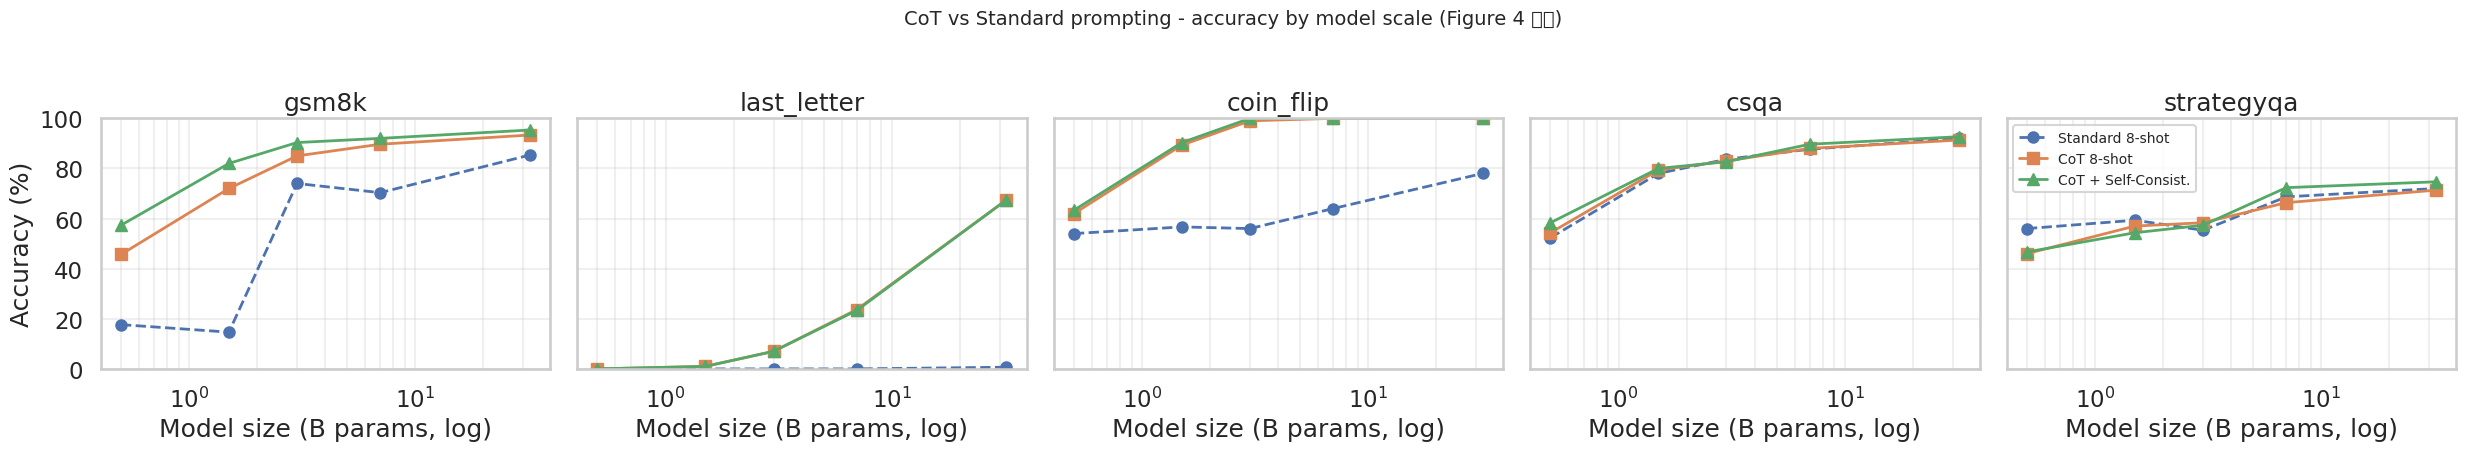

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

cond_styles = {
    "standard":          ("Standard 8-shot",     "o", "--"),
    "cot":               ("CoT 8-shot",          "s", "-"),
    "self_consistency":  ("CoT + Self-Consist.", "^", "-"),
}

fig, axes = plt.subplots(1, len(TASKS), figsize=(5 * len(TASKS), 4.5), sharey=True)
if len(TASKS) == 1:
    axes = [axes]

for ax, task in zip(axes, TASKS):
    sub = df[df["task"] == task].copy()
    for cond, (label, marker, ls) in cond_styles.items():
        s = sub[sub["condition"] == cond].sort_values("params_b")
        if s.empty:
            continue
        ax.plot(s["params_b"], s["accuracy"] * 100,
                marker=marker, linestyle=ls, label=label, markersize=8, linewidth=2)
    ax.set_xscale("log")
    ax.set_title(task)
    ax.set_xlabel("Model size (B params, log)")
    ax.set_ylim(0, 100)
    ax.grid(True, which="both", alpha=0.3)

axes[0].set_ylabel("Accuracy (%)")
axes[-1].legend(loc="best", fontsize=10)
fig.suptitle("CoT vs Standard prompting - accuracy by model scale (Figure 4 재현)",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "figure4_replication.png", dpi=150, bbox_inches="tight")
plt.show()

### 10.4 모델별 조건 간 gap 막대그래프

각 모델에서 Standard / CoT / SC 가 어떻게 차이나는지 한눈에. 모델마다 별도 subplot으로 분리해 데이터가 섞이지 않도록 표시.


/tmp/ipykernel_5712/3957532176.py:32: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5712/3957532176.py:32: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5712/3957532176.py:32: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5712/3957532176.py:32: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5712/3957532176.py:32: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5712/3957532176.py:32: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5712/3957532176.py:32: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tigh

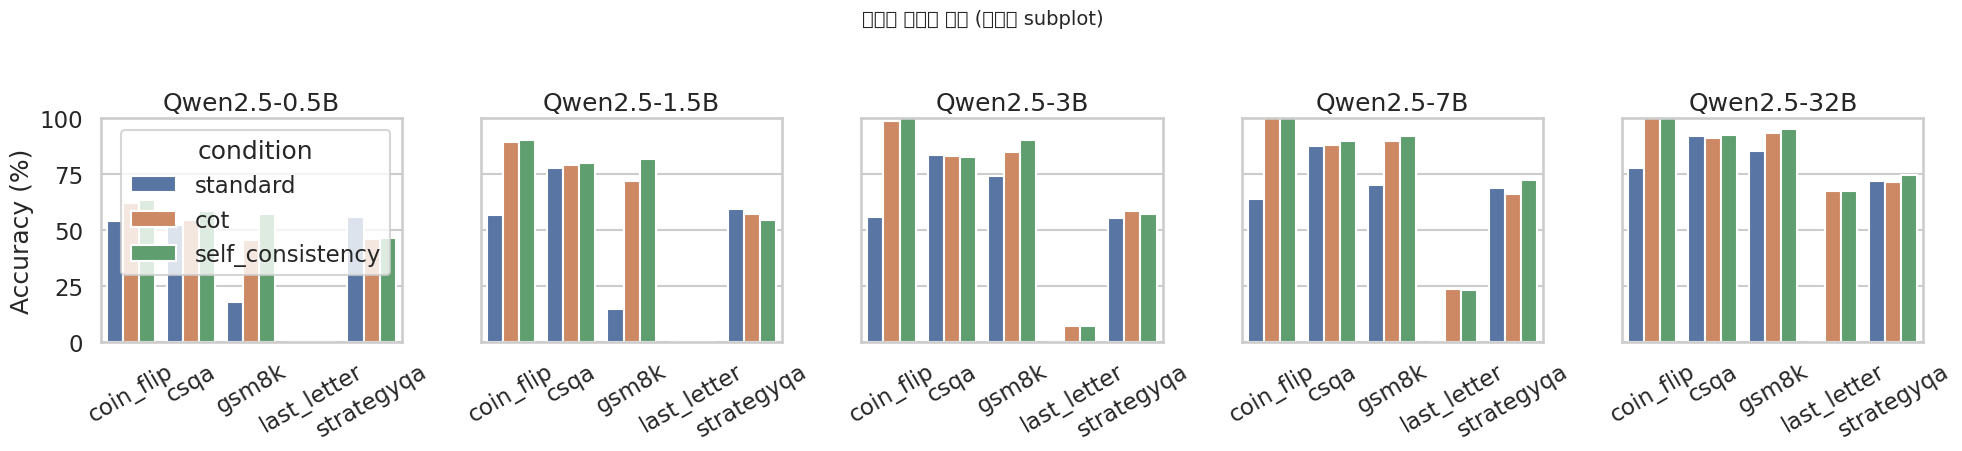

In [ ]:
# 5개 모델을 한 행 5 subplot으로 비교 (모델별로 독립 plot이라 7B와 32B가 섞이지 않음)
target_models = [m[1] for m in VLLM_MODELS]   # 0.5B ~ 32B 전부
n_models = len(target_models)

fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4.5), sharey=True)
if n_models == 1:
    axes = [axes]

for ax, model_name in zip(axes, target_models):
    sub = df[df["model"] == model_name].copy()
    g = (sub.pivot_table(index="task", columns="condition", values="accuracy") * 100).reset_index()
    melted = g.melt(id_vars=["task"], var_name="condition", value_name="acc")
    sns.barplot(data=melted, x="task", y="acc", hue="condition", ax=ax,
                hue_order=["standard", "cot", "self_consistency"])
    ax.set_ylim(0, 100)
    ax.set_title(model_name)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    if ax is not axes[0]:
        ax.set_ylabel("")
        ax.get_legend().remove() if ax.get_legend() else None
    else:
        ax.set_ylabel("Accuracy (%)")

# 첫 번째 subplot에만 legend 유지, 나머지는 깔끔히 숨김
for ax in axes[1:]:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

fig.suptitle("조건별 정확도 비교 (모델별 subplot)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "condition_comparison_bar.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. 결론

위 표와 그래프를 보고 논문의 세 가지 주장을 직접 확인하세요:

1. **주장 1 (CoT > Standard)**: `delta_cot` 표에서 양수가 많을수록 CoT의 이득. 특히 GSM8K처럼 다단계 reasoning이 필요한 태스크에서 큰 양수가 나와야 함.

2. **주장 2 (emergent ability)**: Figure 4에서 Standard 선과 CoT 선이 작은 모델에서는 비슷하다가 모델이 커질수록 벌어지면 emergent 패턴. 또한 `delta_cot` 표를 모델 크기 순으로 보면 행을 따라 값이 커지는 추세가 보여야 함. 다만 Qwen2.5 같은 instruction-tuned 모델은 작은 크기에서도 CoT 효과가 어느 정도 나오는 경향이 있어, 원 논문의 "0.4B에서는 거의 0%" 같은 극단적 kink는 약하게만 나타날 수 있음. 우리 ladder 상한인 32B도 논문 emergent threshold(~62B)에 못 미쳐 "급격한 점프"보다는 점진적 증가가 보일 가능성이 높음.

3. **주장 3 (Self-Consistency > CoT)**: `delta_sc_vs_cot` 표에서 양수가 많을수록 SC의 추가 이득. Figure 4에서는 SC 선이 CoT 선 위에. 보통 GSM8K 같은 numeric task에서 가장 큰 이득.

### 한계
- 평가 문항 수가 적음 (300, 32B는 150). 정확도 ±3~5%p 노이즈는 normal.
- 원 논문 모델 크기(0.4B ~ 540B)에 비해 우리 ladder(0.5B ~ 32B)는 좁고 상한도 emergent threshold 미달.
- 32B는 AWQ 4bit 양자화 모델이라 fp16 대비 약간의 정확도 손실이 있을 수 있음 (보통 ≤1%p).
- Instruct-tuned 모델은 base 모델과 prompt 친숙도가 달라 CoT가 작은 모델에서도 어느 정도 작동할 수 있음.
- 답 추출 regex는 100% 정확하지 않음 — `extraction_failed` / `extraction_fallback` 카운트로 모니터링.

`results/raw/` 에 모든 모델 응답 원본이 JSONL로 저장돼 있어 추가 분석/디버깅이 가능합니다.
